# Module 03 - A First Neural Network

Use this notebook as the working space for the Module 03 exercises.

1. Read the lesson page (`docs/modules/03-nn.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 03`.
3. Answer the `Question:` / `Answer:` cells below.
4. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from g2c.nn import CrossEntropyLoss, Linear, MSELoss, ReLU, SGD, Sequential

torch.manual_seed(0)

## Before the Notebook

Use the tests to implement the library pieces first. The notebook assumes `Linear`, activations, `Sequential`, `CrossEntropyLoss`, and `SGD.step` are working.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_nn.py -x"
"Question: Which test is the next one failing, and what implementation does it point at?"
"Answer: "

'Answer: '

## Exercise 1 - Linear Regression

Fit noisy samples from `y = 3x + 2` using one `Linear(1, 1)` layer. The point is to write the training loop yourself: zero gradients, forward pass, scalar loss, backward pass, optimizer step.

In [3]:
torch.manual_seed(0)
x_reg = torch.linspace(-1.0, 1.0, 100).unsqueeze(1)
y_reg = 3.0 * x_reg + 2.0 + 0.05 * torch.randn_like(x_reg)

print("x_reg:", tuple(x_reg.shape))
print("y_reg:", tuple(y_reg.shape))

x_reg: (100, 1)
y_reg: (100, 1)


In [4]:
"Question: What are the shapes of W, b, predictions, and loss for Linear(1, 1)?"
"Answer: "

"Question: Why must optimizer.zero_grad() run before loss.backward()?"
"Answer: "

"Question: Why must optimizer.step() happen after loss.backward()?"
"Answer: "

'Answer: '

In [5]:
def train_linear_regression(
    x: torch.Tensor,
    y: torch.Tensor,
    steps: int = 500,
    lr: float = 0.1,
) -> tuple[Linear, list[float]]:
    """Train Linear(1, 1) on x -> y and return (model, losses)."""
    model = Linear(1, 1)
    loss_fn = MSELoss()
    optimizer = SGD(model.parameters(), lr=lr)
    losses: list[float] = []

    def train_step() -> float:
        # TODO: zero gradients
        # TODO: compute predictions with model(x)
        # TODO: compute scalar loss with loss_fn(...)
        # TODO: backpropagate with loss.backward()
        # TODO: update parameters with optimizer.step()
        # TODO: return float(loss.item())
        raise NotImplementedError("fill in one training step")

    for _ in range(steps):
        losses.append(train_step())

    return model, losses

In [6]:
linear_model, linear_losses = train_linear_regression(x_reg, y_reg)

print("learned W:", linear_model.W.item())
print("learned b:", linear_model.b.item())
print("final loss:", linear_losses[-1])

assert abs(linear_model.W.item() - 3.0) < 0.15
assert abs(linear_model.b.item() - 2.0) < 0.15

plt.plot(linear_losses)
plt.xlabel("step")
plt.ylabel("MSE")
plt.title("Linear regression training loss")
plt.show()

NotImplementedError: fill in one training step

In [7]:
"Question: Did the learned W and b recover the true line? What evidence supports your answer?"
"Answer: "

"Question: If the loss diverged or became NaN, what would you try first?"
"Answer: "

'Answer: '

## Exercise 2 - A 2D Classifier

Train a small MLP on a nonlinear 2D dataset. The dataset helper is provided; you implement the model construction and training loop.

x_2d: (400, 2)
y_2d: (400,)


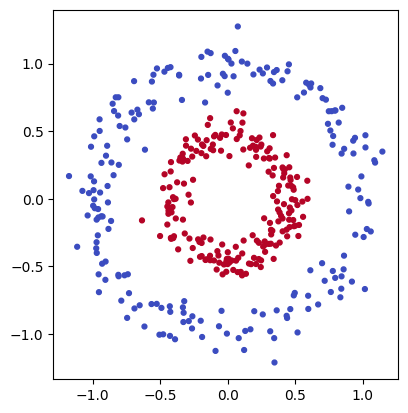

In [8]:
def make_circles_torch(n: int = 400, noise: float = 0.08) -> tuple[torch.Tensor, torch.Tensor]:
    n_outer = n // 2
    n_inner = n - n_outer
    outer_theta = 2 * math.pi * torch.rand(n_outer)
    inner_theta = 2 * math.pi * torch.rand(n_inner)

    outer = torch.stack([torch.cos(outer_theta), torch.sin(outer_theta)], dim=1)
    inner = 0.45 * torch.stack([torch.cos(inner_theta), torch.sin(inner_theta)], dim=1)
    x = torch.cat([outer, inner], dim=0) + noise * torch.randn(n, 2)
    y = torch.cat([torch.zeros(n_outer), torch.ones(n_inner)]).long()
    return x, y


x_2d, y_2d = make_circles_torch()
print("x_2d:", tuple(x_2d.shape))
print("y_2d:", tuple(y_2d.shape))

plt.scatter(x_2d[:, 0], x_2d[:, 1], c=y_2d, s=12, cmap="coolwarm")
plt.gca().set_aspect("equal")
plt.show()

In [9]:
"Question: Why can a single Linear(2, 2) layer not solve these circles well?"
"Answer: "

"Question: What shape should the logits have for this 2-class problem?"
"Answer: "

"Question: Why should the final layer output logits, not probabilities?"
"Answer: "

'Answer: '

In [10]:
def build_2d_classifier(hidden: int = 16) -> Sequential:
    """Return a small nonlinear classifier for inputs shaped (B, 2)."""
    # TODO: compose Linear(2, hidden), ReLU(), Linear(hidden, 2)
    # TODO: return the Sequential model
    raise NotImplementedError("build a 2-layer MLP with one ReLU")


def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """Return classification accuracy as a Python float.

    Accuracy is an evaluation metric, not a loss. CrossEntropyLoss uses the
    full logits because confidence matters for training. Accuracy only asks
    which class had the largest logit for each example.

    Shapes:
      logits:  (B, C)  raw class scores
      targets: (B,)    correct class ids

    Steps:
      1. preds = logits.argmax(dim=-1)          # shape (B,)
      2. correct = preds == targets             # bool tensor, shape (B,)
      3. return correct.float().mean().item()
    """
    # TODO: implement the three steps above.
    raise NotImplementedError("compute argmax accuracy")

In [11]:
def train_classifier(
    model: Sequential,
    x: torch.Tensor,
    y: torch.Tensor,
    steps: int = 1000,
    lr: float = 0.1,
    weight_decay: float = 0.0,
) -> list[float]:
    """Train a classifier on all examples at once and return losses."""
    loss_fn = CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    losses: list[float] = []

    def train_step() -> float:
        # TODO: zero gradients
        # TODO: logits = model(x)
        # TODO: loss = loss_fn(logits, y)
        # TODO: backward and optimizer step
        # TODO: return float(loss.item())
        raise NotImplementedError("fill in one classifier training step")

    for _ in range(steps):
        losses.append(train_step())

    return losses

In [12]:
circle_model = build_2d_classifier(hidden=16)
circle_losses = train_classifier(circle_model, x_2d, y_2d, steps=1000, lr=0.1)
circle_logits = circle_model(x_2d)
circle_acc = accuracy_from_logits(circle_logits, y_2d)

print("final loss:", circle_losses[-1])
print("training accuracy:", circle_acc)
assert circle_logits.shape == (x_2d.shape[0], 2)
assert circle_acc > 0.90

plt.plot(circle_losses)
plt.xlabel("step")
plt.ylabel("cross-entropy")
plt.title("2D classifier training loss")
plt.show()

NotImplementedError: build a 2-layer MLP with one ReLU

In [13]:
def plot_decision_boundary(model: Sequential, x: torch.Tensor, y: torch.Tensor) -> None:
    x_min, x_max = x[:, 0].min().item() - 0.3, x[:, 0].max().item() + 0.3
    y_min, y_max = x[:, 1].min().item() - 0.3, x[:, 1].max().item() + 0.3
    xs = torch.linspace(x_min, x_max, 120)
    ys = torch.linspace(y_min, y_max, 120)
    grid_x, grid_y = torch.meshgrid(xs, ys, indexing="xy")
    grid = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=1)

    with torch.no_grad():
        pred = model(grid).argmax(dim=-1).reshape(grid_x.shape)

    plt.contourf(grid_x, grid_y, pred, levels=1, alpha=0.25, cmap="coolwarm")
    plt.scatter(x[:, 0], x[:, 1], c=y, s=12, cmap="coolwarm")
    plt.gca().set_aspect("equal")
    plt.show()


plot_decision_boundary(circle_model, x_2d, y_2d)

NameError: name 'circle_model' is not defined

In [14]:
"Question: What did the ReLU layer let the model do that a single Linear layer cannot?"
"Answer: "

"Question: What evidence tells you the model learned the dataset rather than just running code?"
"Answer: "

'Answer: '

## Exercise 3 - MNIST MLP

This section scaffolds the MNIST deliverable. It intentionally leaves the data loading, model construction, epoch loop, and evaluation pieces for you to complete.

In [15]:
"Question: After flattening MNIST images, what shape should one batch x have?"
"Answer: "

"Question: For Linear(784, 128), what are the shapes of W and b?"
"Answer: "

"Question: Why does CrossEntropyLoss expect class-index targets rather than one-hot vectors here?"
"Answer: "

'Answer: '

In [16]:
def find_repo_root() -> Path:
    """Find the repo root from either notebooks/clean or notebooks/solutions."""
    path = Path.cwd().resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "g2c").exists():
            return candidate
    return path


def load_mnist_subset(
    batch_size: int = 128,
    train_limit: int | None = None,
    test_limit: int | None = None,
):
    """Return train_loader and test_loader for MNIST.

    Loading, normalization, downloading, and DataLoader plumbing are boilerplate,
    so they are provided here. Keep flattening in the training/eval loops so you
    keep seeing the shape transition from (B, 1, 28, 28) to (B, 784).

    Set train_limit/test_limit to small values like 2048/512 for a quick smoke
    run before training on the full dataset.
    """
    from torch.utils.data import DataLoader, Subset
    from torchvision import datasets, transforms

    data_dir = find_repo_root() / "data"
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])

    train_dataset = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform,
    )
    test_dataset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform,
    )

    if train_limit is not None:
        train_dataset = Subset(train_dataset, range(train_limit))
    if test_limit is not None:
        test_dataset = Subset(test_dataset, range(test_limit))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

In [22]:
def build_mnist_mlp(hidden: int = 128, use_relu: bool = True) -> Sequential:
    """Build the Module 03 MNIST MLP."""
    # TODO: with use_relu=True, return Linear(784, hidden) -> ReLU -> Linear(hidden, 10)
    # TODO: with use_relu=False, return the same two Linear layers without ReLU
    return Sequential(Linear(784, hidden), ReLU(), Linear(hidden, 10))

In [23]:
  def train_one_epoch(                                                                                                                                        
      model: Sequential,                                                  
      loader,                                                                                                                                                 
      optimizer: SGD,                                                     
      loss_fn: CrossEntropyLoss,                                                                                                                              
  ) -> float:
      """Train for one epoch and return mean loss."""                                                                                                         
      total_loss = 0.0
      total_examples = 0                                                                                                                                      
      for images, labels in loader:                                                                                                                           
          images = images.view(images.size(0), -1)  # (B, 1, 28, 28) -> (B, 784)
                                                                                                                                                              
          optimizer.zero_grad()                                           
          logits = model(images)                                                                                                                              
          loss = loss_fn(logits, labels)                                  
          loss.backward()
          optimizer.step()

          batch_size = images.size(0)                                                                                                                         
          total_loss += loss.item() * batch_size
          total_examples += batch_size                                                                                                                        
      return total_loss / total_examples                                  

                                                                                                                                                              
  def evaluate_accuracy(model: Sequential, loader) -> float:
      """Return classification accuracy on a loader."""                                                                                                       
      correct = 0                                                         
      total = 0
      with torch.no_grad():
          for images, labels in loader:
              images = images.view(images.size(0), -1)                                                                                                        
              logits = model(images)
              preds = logits.argmax(dim=1)                                                                                                                    
              correct += (preds == labels).sum().item()                   
              total += labels.size(0)                                                                                                                         
      return correct / total

In [27]:
from g2c.notebook_extras.nn import (
    plot_mnist_training_curves,
    plot_sample_predictions,
)

USE_FULL_MNIST = True

if USE_FULL_MNIST:
    train_loader, test_loader = load_mnist_subset(batch_size=128)
    target_accuracy = 0.95
else:
    train_loader, test_loader = load_mnist_subset(
        batch_size=128,
        train_limit=2048,
        test_limit=512,
    )
    target_accuracy = 0.85

mnist_model = build_mnist_mlp(hidden=12, use_relu=True)
mnist_loss_fn = CrossEntropyLoss()
mnist_optimizer = SGD(mnist_model.parameters(), lr=0.1)

# Pick a fixed slice of test images to track across epochs. shuffle=False
# on the test loader makes this deterministic.
sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:30]
sample_labels = sample_labels[:30]

train_losses: list[float] = []
test_accuracies: list[float] = []
predictions_per_epoch: list = []
epochs = 5
for epoch in range(epochs):
    train_loss = train_one_epoch(mnist_model, train_loader, mnist_optimizer, mnist_loss_fn)
    test_acc = evaluate_accuracy(mnist_model, test_loader)
    with torch.no_grad():
        sample_logits = mnist_model(sample_images.view(sample_images.size(0), -1))
        sample_preds = sample_logits.argmax(dim=1)
    train_losses.append(train_loss)
    test_accuracies.append(test_acc)
    predictions_per_epoch.append(sample_preds)
    print(f"epoch {epoch + 1}: train_loss={train_loss:.4f} test_acc={test_acc:.4f}")

assert test_accuracies[-1] >= target_accuracy

plot_mnist_training_curves(train_losses, test_accuracies)
plot_sample_predictions(sample_images, sample_labels, predictions_per_epoch)

epoch 1: train_loss=0.4135 test_acc=0.9135
epoch 2: train_loss=0.2684 test_acc=0.9270
epoch 3: train_loss=0.2378 test_acc=0.9231
epoch 4: train_loss=0.2209 test_acc=0.9269
epoch 5: train_loss=0.2108 test_acc=0.9337


AssertionError: 

## Exercise 4 - Overfitting and Weight Decay

Use the MNIST helpers to compare a large model trained with and without weight decay. The goal is not just a higher score; it is reading train/validation curves.

In [ ]:
"Question: What pattern in train loss and validation loss indicates overfitting?"
"Answer: "

"Question: In this SGD implementation, where does weight_decay enter the update rule?"
"Answer: "

"Question: What do you predict weight decay will do to the validation curve?"
"Answer: "

In [ ]:
def run_weight_decay_experiment(train_loader, test_loader):
    """Compare a large MNIST MLP with and without weight decay."""
    # TODO: train one large model with weight_decay=0.0
    # TODO: train a second same-size model with weight_decay=1e-4
    # TODO: collect train losses and validation/test accuracies per epoch
    # TODO: plot or return the curves for comparison
    raise NotImplementedError("run the weight-decay comparison")

In [ ]:
weight_decay_results = run_weight_decay_experiment(train_loader, test_loader)
weight_decay_results

## Exercise 5 - Strip the Nonlinearity

Train the same two-layer MNIST model with and without `ReLU()`. This is the algebraic point from the lesson turned into an experiment.

In [ ]:
"Question: Why is Linear -> Linear equivalent to one Linear layer?"
"Answer: "

"Question: What accuracy change do you predict when ReLU is removed?"
"Answer: "

"Question: If the no-ReLU model still improves during training, why does that not contradict the lesson?"
"Answer: "

In [ ]:
def compare_with_and_without_relu(train_loader, test_loader):
    """Train matched MNIST models with use_relu=True and use_relu=False."""
    # TODO: build two models with build_mnist_mlp(..., use_relu=True/False)
    # TODO: train each for the same number of epochs with the same lr
    # TODO: compare test accuracy and loss curves
    raise NotImplementedError("compare the effect of removing ReLU")

In [ ]:
relu_comparison = compare_with_and_without_relu(train_loader, test_loader)
relu_comparison

## Submission Notes

When complete, ask a coding agent to grade your Module 03 notebook. Partial work is fine: the agent should grade answered questions and implemented sections, then skip blank prompts.